# Factor AI Lab 02 — can a neural network improve a PDV velocity trace?

This notebook treats STFT design as an **evaluation problem**. It first searches window length, overlap, window function, and zero padding with a conventional peak-ridge estimator. It then gives a small CNN the same spectrogram information and a fixed training budget.

**Decision:** choose a processing configuration for recovering a non-negative line-of-sight speed magnitude from a real-valued synthetic PDV voltage trace.

**Boundary:** this is synthetic development evidence. It does not validate a real diagnostic, recover signed motion, identify melting, or distinguish ETI from MRTI.

## 0. Freeze the evaluation contract before looking at test results

- Input: one detector-voltage trace and known sampling rate and laser wavelength.
- Output: speed magnitude at each STFT frame center.
- Train: 32 independent synthetic shots. Development: 12 shots.
- Locked test: 12 matched shots plus 12 shifted shots with faster changes, dropout, and a secondary return.
- Baseline: strongest STFT ridge. Candidate: a small temporal CNN.
- Primary metrics: MAE, bias, RMSE, and 95th-percentile absolute error in m/s.
- Provisional acceptance gate: matched MAE ≤ 15 m/s, shifted MAE ≤ 40 m/s, and CNN matched MAE below the selected conventional baseline.

The thresholds are teaching values, not facility requirements. Zero padding samples the spectrum more densely; it does not create new measurement information.

In [61]:
from dataclasses import dataclass, asdict
from itertools import product
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import ShortTimeFFT
import torch
from torch import nn

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
FS = 4.0e9                 # samples/second
WAVELENGTH = 1550e-9       # meters
N_SAMPLES = 1024
MAX_SPEED = 1300.0         # m/s represented by the estimator
N_VELOCITY_BINS = 96
VELOCITY_GRID = np.linspace(0, MAX_SPEED, N_VELOCITY_BINS)
SAMPLE_TIME = np.arange(N_SAMPLES) / FS

print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | device {DEVICE}")
print(f"Trace: {N_SAMPLES} samples, {N_SAMPLES/FS*1e9:.1f} ns | Nyquist speed: {WAVELENGTH*FS/4:.1f} m/s")

Python 3.12.14 | PyTorch 2.14.0 | device mps
Trace: 1024 samples, 256.0 ns | Nyquist speed: 1550.0 m/s


## 1. Transparent synthetic forward model
For normal-incidence heterodyne PDV, speed magnitude and beat frequency follow `v = wavelength × frequency / 2`. We integrate frequency to make optical phase, then record a noisy cosine. The shifted family adds effects that training does not contain. Simulator labels are exact only inside this generator.

In [62]:
def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x*x*(3 - 2*x)

def simulate_shot(seed, family="matched"):
    rng = np.random.default_rng(seed)
    u = np.linspace(0, 1, N_SAMPLES)
    start = rng.uniform(80, 180)
    rise = rng.uniform(450, 760) * smoothstep((u-rng.uniform(.08,.22))/rng.uniform(.55,.8))
    ripple = rng.uniform(20, 75) * np.sin(2*np.pi*(rng.uniform(.7,1.8)*u + rng.random()))
    speed = np.clip(start + rise + ripple, 25, 1150)
    amplitude = 1 + .22*np.sin(2*np.pi*(rng.uniform(.4,1.3)*u+rng.random()))
    secondary = 0.0
    if family == "shifted":
        center = rng.uniform(.42,.7)
        speed += rng.uniform(120,260) * .5*(1+np.tanh((u-center)/rng.uniform(.012,.025)))
        speed = np.clip(speed, 25, MAX_SPEED)
        amplitude *= 1 - rng.uniform(.65,.95)*np.exp(-.5*((u-rng.uniform(.45,.75))/rng.uniform(.025,.06))**2)
        other_speed = np.clip(speed + rng.uniform(120,260), 0, MAX_SPEED)
        other_phase = 2*np.pi*np.cumsum(2*other_speed/WAVELENGTH)/FS + rng.uniform(0,2*np.pi)
        secondary = rng.uniform(.18,.4)*np.cos(other_phase)
    beat_frequency = 2*speed/WAVELENGTH
    phase = 2*np.pi*np.cumsum(beat_frequency)/FS + rng.uniform(0,2*np.pi)
    drift = rng.uniform(.05,.18)*np.sin(2*np.pi*rng.uniform(4e6,16e6)*SAMPLE_TIME+rng.random())
    noise = rng.normal(0, rng.uniform(.08,.2), N_SAMPLES)
    voltage = amplitude*np.cos(phase) + secondary + drift + noise
    return {"seed": seed, "family": family, "voltage": voltage.astype("float32"),
            "speed": speed.astype("float32")}

train_shots = [simulate_shot(1000+i) for i in range(32)]
dev_shots = [simulate_shot(2000+i) for i in range(12)]
test_matched = [simulate_shot(3000+i) for i in range(12)]
test_shifted = [simulate_shot(4000+i, "shifted") for i in range(12)]
print("Independent shot split:", len(train_shots), len(dev_shots), len(test_matched), len(test_shifted))

Independent shot split: 32 12 12 12


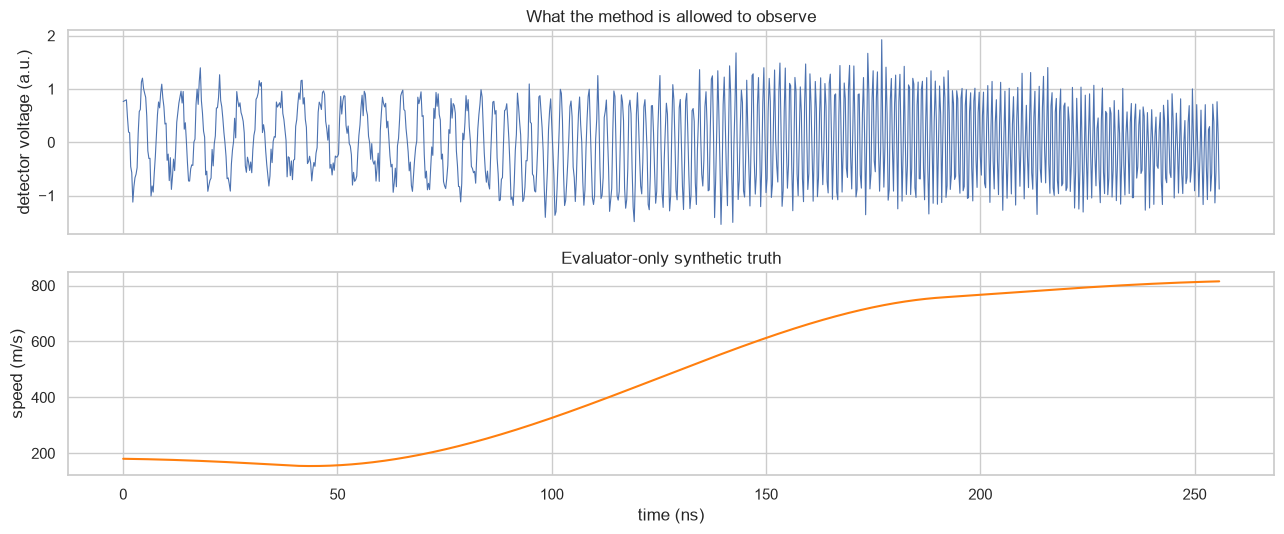

In [63]:
example = train_shots[0]
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(SAMPLE_TIME*1e9, example["voltage"], linewidth=.8)
axes[0].set(ylabel="detector voltage (a.u.)", title="What the method is allowed to observe")
axes[1].plot(SAMPLE_TIME*1e9, example["speed"], color="tab:orange")
axes[1].set(xlabel="time (ns)", ylabel="speed (m/s)", title="Evaluator-only synthetic truth")
plt.tight_layout(); plt.show()

## 2. STFT configurations and the conventional baseline
A long window improves frequency resolution but smears fast changes in time. More overlap produces more time samples and more computation. Window shape changes leakage. Zero padding gives a denser frequency grid without adding information.

In [64]:
@dataclass(frozen=True)
class STFTConfig:
    window_length: int
    overlap: float
    window: str
    zero_pad: int

CONFIGS = [STFTConfig(*values) for values in product(
    [24, 48, 96, 192], [.25, .50, .75], ["hann", "blackman"], [1, 2, 4, 8, 16])]

def transform(shot, config):
    noverlap = int(config.window_length * config.overlap)
    nfft = config.window_length * config.zero_pad
    stft = ShortTimeFFT.from_window(config.window, fs=FS, nperseg=config.window_length,
                                    noverlap=noverlap, mfft=nfft, scale_to="magnitude")
    magnitude = np.abs(stft.stft(shot["voltage"]))
    frame_time = stft.t(N_SAMPLES)
    inside = (frame_time >= 0) & (frame_time <= SAMPLE_TIME[-1])
    frame_time, magnitude = frame_time[inside], magnitude[:, inside]
    native_velocity = WAVELENGTH * stft.f / 2
    usable = native_velocity <= MAX_SPEED
    resized = np.stack([np.interp(VELOCITY_GRID, native_velocity[usable], magnitude[usable, j])
                        for j in range(magnitude.shape[1])], axis=1)
    db = 20*np.log10(resized/(resized.max()+1e-12)+1e-6)
    features = np.clip((db+60)/60, 0, 1).astype("float32")
    truth = np.interp(frame_time, SAMPLE_TIME, shot["speed"]).astype("float32")
    return features, truth, frame_time

def ridge_prediction(features):
    return VELOCITY_GRID[np.argmax(features, axis=0)]

def metrics(prediction, truth):
    error = np.concatenate(prediction) - np.concatenate(truth)
    return {"mae": np.mean(np.abs(error)), "bias": np.mean(error),
            "rmse": np.sqrt(np.mean(error**2)), "p95": np.percentile(np.abs(error),95)}

def score_ridge(config, shots):
    predictions, truths = [], []
    for shot in shots:
        features, truth, _ = transform(shot, config)
        predictions.append(ridge_prediction(features)); truths.append(truth)
    return metrics(predictions, truths)

started = time.perf_counter()
ridge_rows = []
for config in CONFIGS:
    score = score_ridge(config, dev_shots)
    hop = config.window_length - int(config.window_length*config.overlap)
    ridge_rows.append({**asdict(config), **score, "time_resolution_ns": hop/FS*1e9,
                       "velocity_bin_ms": WAVELENGTH*FS/(2*config.window_length*config.zero_pad)})
ridge_search = pd.DataFrame(ridge_rows).sort_values("mae").reset_index(drop=True)
print(f"Evaluated {len(CONFIGS)} configurations on development shots in {time.perf_counter()-started:.2f} s")
ridge_search.head(8).round(2)

Evaluated 120 configurations on development shots in 1.05 s


,window_length,overlap,window,zero_pad,mae,bias,rmse,p95,time_resolution_ns,velocity_bin_ms
0,96,0.75,hann,8,3.67,-0.09,4.54,7.41,6.0,4.04
1,96,0.75,hann,16,3.67,-0.06,4.55,7.41,6.0,2.02
2,96,0.75,blackman,8,3.67,-0.03,4.55,7.41,6.0,4.04
3,96,0.75,blackman,16,3.68,-0.03,4.56,7.46,6.0,2.02
4,96,0.75,hann,4,3.69,0.07,4.57,7.45,6.0,8.07
5,96,0.75,blackman,4,3.72,0.12,4.62,7.51,6.0,8.07
6,96,0.75,blackman,2,3.75,0.18,4.67,7.83,6.0,16.15
7,96,0.75,hann,2,3.75,0.07,4.67,7.88,6.0,16.15


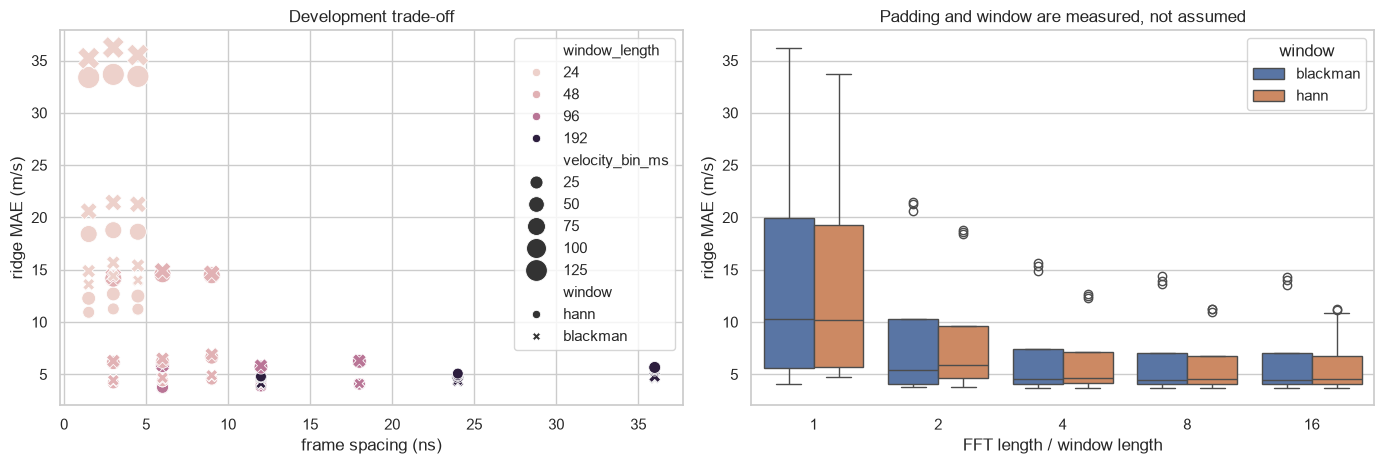

Selected conventional configuration from development data: STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=8)


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.scatterplot(data=ridge_search, x="time_resolution_ns", y="mae", size="velocity_bin_ms",
                hue="window_length", style="window", sizes=(50,250), ax=axes[0])
axes[0].set(title="Development trade-off", xlabel="frame spacing (ns)", ylabel="ridge MAE (m/s)")
sns.boxplot(data=ridge_search, x="zero_pad", y="mae", hue="window", ax=axes[1])
axes[1].set(title="Padding and window are measured, not assumed", xlabel="FFT length / window length", ylabel="ridge MAE (m/s)")
plt.tight_layout(); plt.show()

best_ridge_row = ridge_search.iloc[0]
BEST_RIDGE_CONFIG = STFTConfig(int(best_ridge_row.window_length), float(best_ridge_row.overlap),
                               str(best_ridge_row.window), int(best_ridge_row.zero_pad))
print("Selected conventional configuration from development data:", BEST_RIDGE_CONFIG)

## 3. Train the neural candidate
The CNN reads the normalized spectrogram and predicts one speed per STFT frame. To keep the compute comparison bounded, we train only the top three configurations from the conventional development sweep, using the same architecture, epochs, and optimizer. Change `CNN_CONFIG_BUDGET` to search more configurations. This shortcut means the notebook does not claim a global neural optimum.

In [66]:
CNN_CONFIG_BUDGET = 1000
CNN_EPOCHS = 3000

class VelocityCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(N_VELOCITY_BINS, 48, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(48, 24, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(24, 1, kernel_size=1), nn.Sigmoid())
    def forward(self, spectrogram):
        return self.network(spectrogram).squeeze(1) * MAX_SPEED

def batch_for(shots, config):
    transformed = [transform(shot, config) for shot in shots]
    return (torch.tensor(np.stack([item[0] for item in transformed]), device=DEVICE),
            torch.tensor(np.stack([item[1] for item in transformed]), device=DEVICE))

def train_cnn(config, seed=17):
    torch.manual_seed(seed)
    train_features, train_truth = batch_for(train_shots, config)
    dev_features, dev_truth = batch_for(dev_shots, config)
    model = VelocityCNN().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    loss_function = nn.SmoothL1Loss(beta=15.0)
    learning, best = [], {"mae": float("inf"), "state": None}
    for epoch in range(1, CNN_EPOCHS+1):
        model.train(); optimizer.zero_grad()
        train_prediction = model(train_features)
        loss = loss_function(train_prediction, train_truth)
        loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            dev_mae = (model(dev_features)-dev_truth).abs().mean().item()
        learning.append({"epoch": epoch, "train_loss": loss.item(), "dev_mae": dev_mae})
        if dev_mae < best["mae"]:
            best = {"mae": dev_mae, "state": copy.deepcopy(model.state_dict())}
    model.load_state_dict(best["state"]); model.eval()
    return model, pd.DataFrame(learning), best["mae"]

candidate_configs = [STFTConfig(int(row.window_length), float(row.overlap), str(row.window), int(row.zero_pad))
                     for _, row in ridge_search.head(CNN_CONFIG_BUDGET).iterrows()]
cnn_runs = []
started = time.perf_counter()
for number, config in enumerate(candidate_configs, 1):
    model, learning, dev_mae = train_cnn(config, seed=100+number)
    cnn_runs.append({"config": config, "model": model, "learning": learning, "dev_mae": dev_mae})
    print(f"{number}/{len(candidate_configs)} {config} -> development MAE {dev_mae:.2f} m/s")
print(f"CNN search budget: {len(candidate_configs)} configurations × {CNN_EPOCHS} epochs = {time.perf_counter()-started:.1f} s")

1/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=8) -> development MAE 13.78 m/s
2/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=16) -> development MAE 15.58 m/s
3/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=8) -> development MAE 15.26 m/s
4/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=16) -> development MAE 15.68 m/s
5/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=4) -> development MAE 15.49 m/s
6/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=4) -> development MAE 12.18 m/s
7/120 STFTConfig(window_length=96, overlap=0.75, window='blackman', zero_pad=2) -> development MAE 14.13 m/s
8/120 STFTConfig(window_length=96, overlap=0.75, window='hann', zero_pad=2) -> development MAE 14.28 m/s
9/120 STFTConfig(window_length=96, overlap=0.5, window='hann', zero_pad=4) -> development MAE 18.19 m/s
10/120 STFTConfig(window_length=96, ov

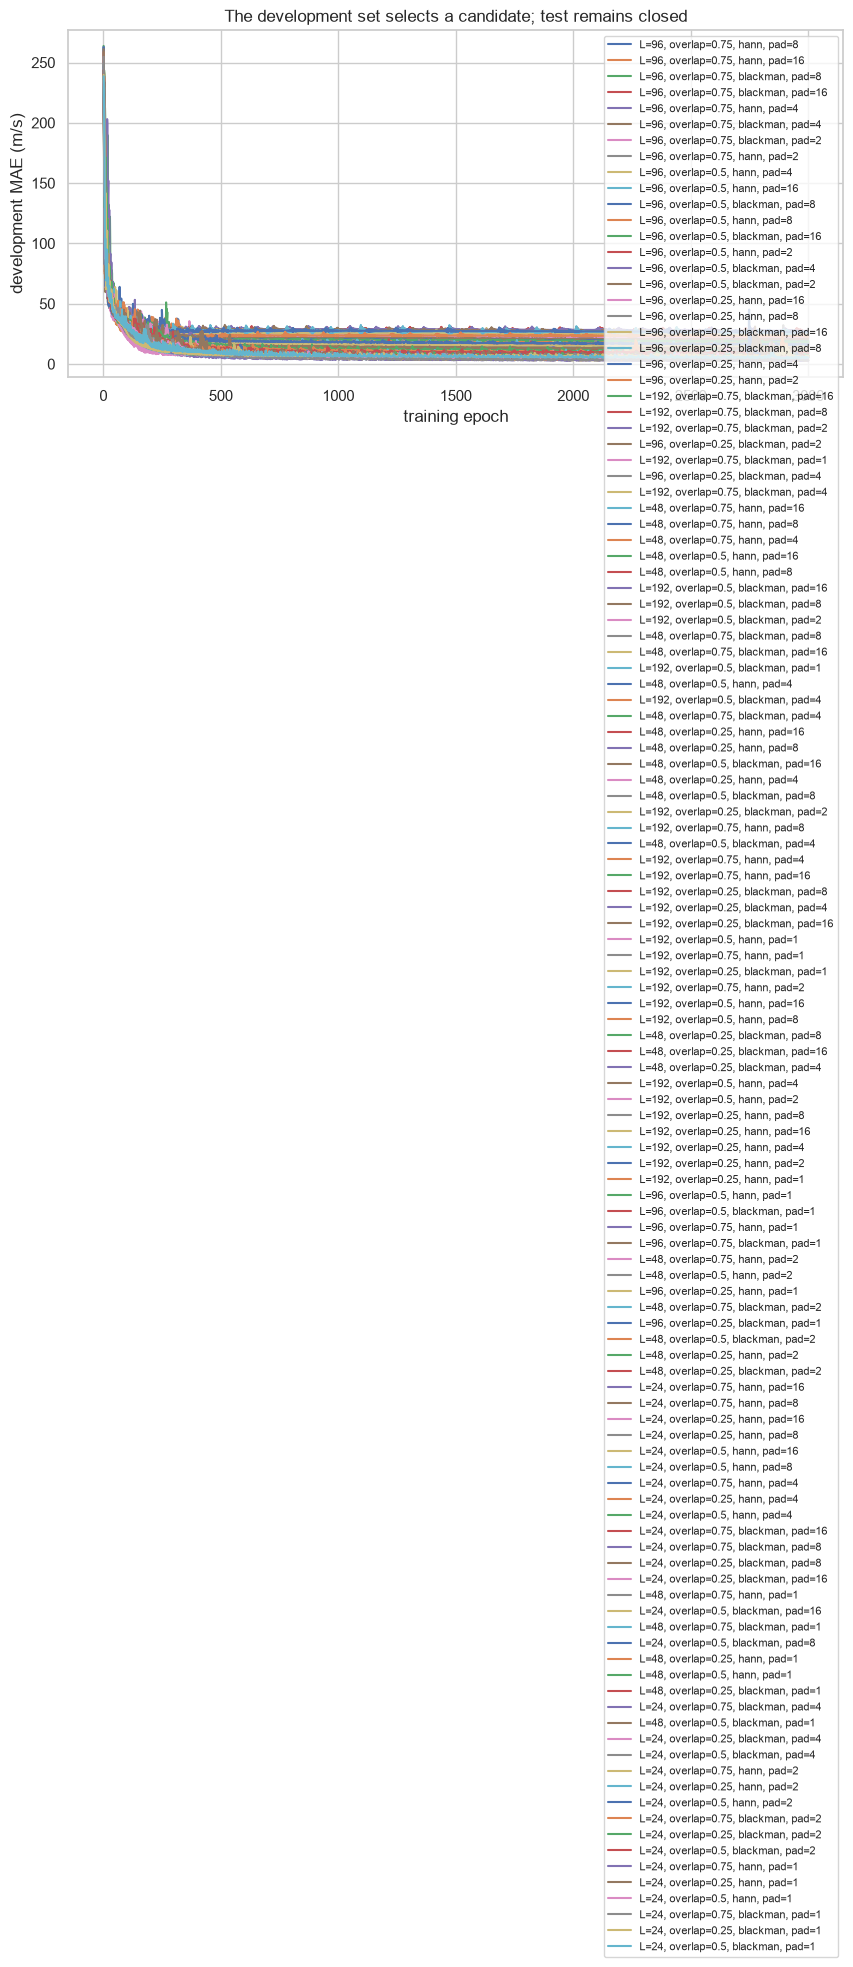

Selected neural configuration: STFTConfig(window_length=24, overlap=0.75, window='hann', zero_pad=2) development MAE=2.61 m/s


In [67]:
fig, ax = plt.subplots(figsize=(10,4.5))
for run in cnn_runs:
    label = f"L={run['config'].window_length}, overlap={run['config'].overlap}, {run['config'].window}, pad={run['config'].zero_pad}"
    ax.plot(run["learning"].epoch, run["learning"].dev_mae, label=label)
ax.set(xlabel="training epoch", ylabel="development MAE (m/s)", title="The development set selects a candidate; test remains closed")
ax.legend(fontsize=8); plt.show()
best_cnn = min(cnn_runs, key=lambda run: run["dev_mae"])
print("Selected neural configuration:", best_cnn["config"], f"development MAE={best_cnn['dev_mae']:.2f} m/s")

## 4. Open the locked test once
Matched tests ask whether the method generalizes to new draws from the training family. Shifted tests ask whether it survives faster acceleration, lost optical return, and a second return. We report both instead of averaging away failure.

In [68]:
def cnn_predictions(model, config, shots):
    features, truth = batch_for(shots, config)
    with torch.no_grad(): prediction = model(features).cpu().numpy()
    return [row for row in prediction], [row for row in truth.cpu().numpy()]

test_rows = []
for regime, shots in [("matched", test_matched), ("shifted", test_shifted)]:
    ridge_prediction_list, ridge_truth = [], []
    for shot in shots:
        features, truth, _ = transform(shot, BEST_RIDGE_CONFIG)
        ridge_prediction_list.append(ridge_prediction(features)); ridge_truth.append(truth)
    test_rows.append({"method": "STFT ridge", "regime": regime, **metrics(ridge_prediction_list, ridge_truth)})
    pred, truth = cnn_predictions(best_cnn["model"], best_cnn["config"], shots)
    test_rows.append({"method": "STFT + CNN", "regime": regime, **metrics(pred, truth)})
test_results = pd.DataFrame(test_rows)
test_results.round(2)

,method,regime,mae,bias,rmse,p95
0,STFT ridge,matched,3.66,0.33,4.47,7.36
1,STFT + CNN,matched,2.30,-0.34,3.69,5.90
2,STFT ridge,shifted,13.98,2.56,56.92,27.44
3,STFT + CNN,shifted,52.62,-11.45,94.05,204.13


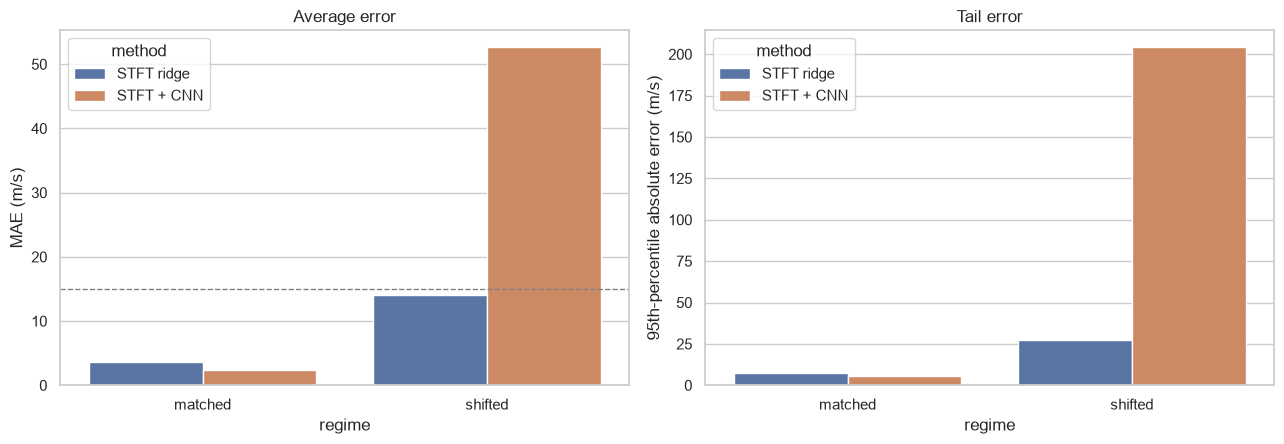

PROVISIONAL GATE: FAIL
Matched improvement versus ridge: 1.35 m/s
A failed gate is useful: it tells us the neural method or the available signal needs a specific change.


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.6))
sns.barplot(data=test_results, x="regime", y="mae", hue="method", ax=axes[0])
axes[0].axhline(15, color="gray", linestyle="--", linewidth=1, label="matched gate")
axes[0].set(title="Average error", ylabel="MAE (m/s)")
sns.barplot(data=test_results, x="regime", y="p95", hue="method", ax=axes[1])
axes[1].set(title="Tail error", ylabel="95th-percentile absolute error (m/s)")
plt.tight_layout(); plt.show()

cnn_matched = test_results.query("method == 'STFT + CNN' and regime == 'matched'").iloc[0]
cnn_shifted = test_results.query("method == 'STFT + CNN' and regime == 'shifted'").iloc[0]
ridge_matched = test_results.query("method == 'STFT ridge' and regime == 'matched'").iloc[0]
accepted = cnn_matched.mae <= 15 and cnn_shifted.mae <= 40 and cnn_matched.mae < ridge_matched.mae
print("PROVISIONAL GATE:", "PASS" if accepted else "FAIL")
print(f"Matched improvement versus ridge: {ridge_matched.mae-cnn_matched.mae:.2f} m/s")
print("A failed gate is useful: it tells us the neural method or the available signal needs a specific change.")

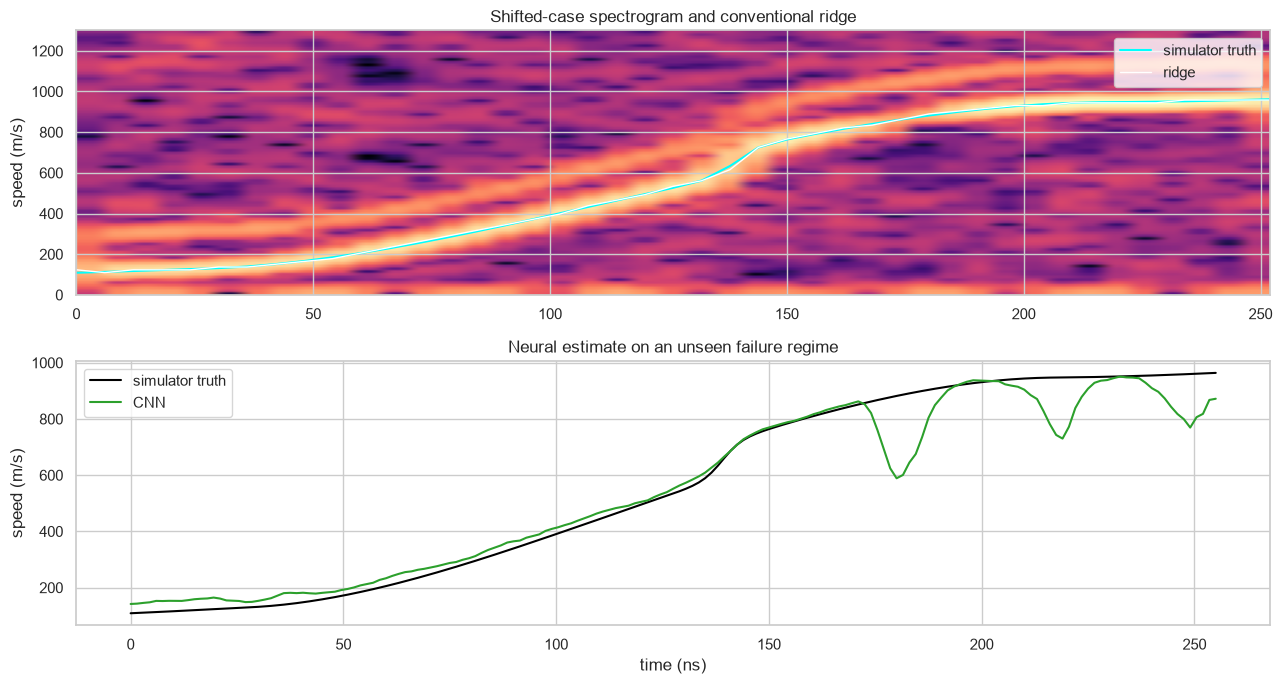

In [70]:
# Inspect one difficult shifted shot instead of trusting only aggregate scores.
shot = test_shifted[0]
ridge_features, ridge_truth, ridge_time = transform(shot, BEST_RIDGE_CONFIG)
ridge_trace = ridge_prediction(ridge_features)
cnn_features, cnn_truth, cnn_time = transform(shot, best_cnn["config"])
with torch.no_grad():
    cnn_trace = best_cnn["model"](torch.tensor(cnn_features[None], device=DEVICE)).cpu().numpy()[0]
fig, axes = plt.subplots(2,1,figsize=(13,7),sharex=False)
axes[0].imshow(ridge_features, origin="lower", aspect="auto",
               extent=[ridge_time[0]*1e9,ridge_time[-1]*1e9,0,MAX_SPEED], cmap="magma")
axes[0].plot(ridge_time*1e9, ridge_truth, color="cyan", label="simulator truth")
axes[0].plot(ridge_time*1e9, ridge_trace, color="white", linewidth=1, label="ridge")
axes[0].set(ylabel="speed (m/s)", title="Shifted-case spectrogram and conventional ridge"); axes[0].legend()
axes[1].plot(cnn_time*1e9, cnn_truth, color="black", label="simulator truth")
axes[1].plot(cnn_time*1e9, cnn_trace, color="tab:green", label="CNN")
axes[1].set(xlabel="time (ns)", ylabel="speed (m/s)", title="Neural estimate on an unseen failure regime"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. What this result can and cannot decide

This notebook can compare processing choices **within its synthetic contract**. It cannot tell us the best settings for Mykonos or MagLIF data until we supply the real sampling rate, wavelength, bandwidth, noise, optical-return behavior, calibration, timing convention, and an independent reference or uncertainty model.

The most useful next input is one de-identified raw PDV waveform with its sample interval, laser wavelength, trigger reference, front-end bandwidth, and the existing analyst reconstruction. That is enough to test whether the synthetic nuisance model resembles reality without claiming the analyst trace is perfect truth.

## Experiments for you
1. Increase `CNN_CONFIG_BUDGET` from 3 to 24. Does the selected STFT configuration change? Record the extra time.
2. Add a Tukey window to `CONFIGS`. Freeze the change before rerunning the test.
3. Remove zero padding. Compare bin spacing with actual error.
4. Make the velocity change twice as fast. Which window length wins?
5. Add a second return to training. Does shifted performance improve, and does matched performance regress?
6. Train three random seeds. Report the distribution instead of the best run.
7. Add an abstention output for low optical return and score false confidence.